# Why does recovery differ across structures that share the exact same peptide?

Two natural replicate groups exist in the twenty-structure panel -- crystals with the identical native
peptide sequence, solved independently:
- **GILGFVFTL** (influenza matrix M1, classic HLA-A2 epitope): 1OGA, 2VLR
- **SLLMWITQC** (NY-ESO-1): 2P5W, 2BNR, 2F53, 2F54

Since the peptide sequence is held fixed within each group, any recovery difference between group
members cannot come from sequence itself -- it must come from something else: TCR identity, crystal
quality, or a genuine difference in how the peptide backbone is actually bound. This notebook checks
each candidate directly.

1. Recovery per replicate-group member
2. Is the TCR actually the same clone, or different?
3. Crystal quality (resolution, B-factor) per member
4. Contact geometry (TCR/MHC) per member
5. Peptide backbone conformation: is it really the same shape? (Kabsch superposition + RMSD)
6. Synthesis: which candidate factor actually tracks the recovery differences?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel4_replicate_structures"
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
# Every (structure, arm, model) cell is truncated to the same number of designs. The raw
# counts differ slightly by generator (9,984 / 10,000 / 10,016), and unique-design counts
# scale with sample size, so comparisons across cells need a common N. 9,984 is the largest
# N every cell can supply; designs are i.i.d. draws, so a prefix is a valid subsample.
N_DESIGNS = 10000
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
CONDITIONS = ["full", "mhconly"]
COND_LABEL = {"full": "pMHC+TCR", "mhconly": "pMHC only"}

# the seven structures held out of the 43-structure analysis set: two mouse H-2Ld and
# five MHC class II. They are not part of any figure in the manuscript.
CONTROLS = ["2E7L", "2OI9", "3C60", "4P23", "4P5T", "3QIB", "4OZG"]

STRUCTS = ["2P5W", "1QSF", "1QRN", "2BNR", "2GJ6", "2F53", "2F54", "3QDG", "3QEQ", "3QFJ", "3GSN",
           "1OGA", "3UTS", "5C0A", "5C0B", "5HHO", "5EU6", "2VLR", "4MJI", "5NME",
           "1BD2", "1LP9", "1MI5", "1QSE", "2AK4", "2BNQ", "2E7L", "2J8U", "2JCC", "2OI9",
           "2PYE", "2UWE", "3C60", "3D3V", "3H9S", "3PWP", "3QDJ", "3QIB", "4FTV", "4JFD",
           "4JFE", "4JFF", "4L3E", "4MNQ", "4OZG", "4P23", "4P5T", "5E9D", "6AM5", "6AMU"]
STRUCTS = [p for p in STRUCTS if p not in CONTROLS]

dataset = pd.read_csv(ROOT / "inputs/pmhc_tcr_dataset/dataset.csv")
# every peptide solved in more than one crystal, taken from the dataset rather than fixed by
# hand, so the replicate set tracks whatever structures are present
_pool = dataset[dataset.pdb.isin(STRUCTS)]
GROUPS = {pep: [p for p in STRUCTS if p in set(g)]
          for pep, g in _pool.groupby("peptide")["pdb"].apply(list).items() if len(g) >= 2}
GROUPS = dict(sorted(GROUPS.items(), key=lambda kv: (-len(kv[1]), kv[0])))
for pep, pdbs in GROUPS.items():
    print(f"{pep}: {pdbs}")

SLLMWITQC: ['2P5W', '2BNR', '2F53', '2F54', '2PYE']
ALWGFFPVL: ['1LP9', '2J8U', '2JCC', '2UWE']
ELAGIGILTV: ['3QDG', '4JFF', '4L3E', '5E9D']
AAGIGILTV: ['3QEQ', '3QDJ']
GILGFVFTL: ['1OGA', '2VLR']
LLFGFPVYV: ['3QFJ', '3D3V']
LLFGYPVYV: ['1BD2', '4FTV']


## 1. Recovery per replicate-group member

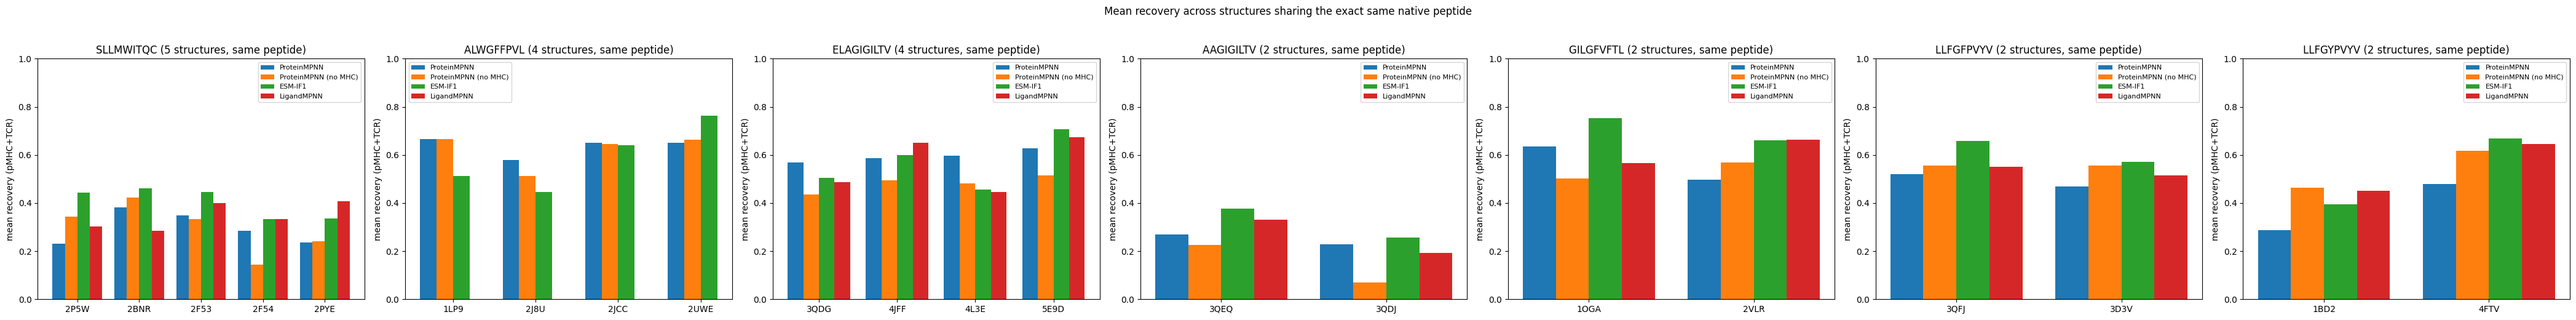

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_recovery_by_replicate.png
model             ESM-IF1  LigandMPNN     noMHC   vanilla
peptide    pdb                                           
AAGIGILTV  3QDJ  0.256378    0.193034  0.071018  0.228265
           3QEQ  0.377333    0.331500  0.226678  0.268233
ALWGFFPVL  1LP9  0.512811         NaN  0.666700  0.666589
           2J8U  0.446678         NaN  0.511745  0.577789
           2JCC  0.640500         NaN  0.645413  0.649163
           2UWE  0.761956         NaN  0.663451  0.650008
ELAGIGILTV 3QDG  0.504400    0.486010  0.436610  0.567500
           4JFF  0.599240    0.649925  0.495233  0.587742
           4L3E  0.457220    0.446610  0.482344  0.596865
           5E9D  0.707260    0.674031  0.513671  0.628162
GILGFVFTL  1OGA  0.752044    0.567244  0.500789  0.635833
           2VLR  0.660089    0.664300  0.569800  0.498144
LLFGFPVYV  3D3V  0.570156    0.515751  0.555478  0.469816
           3QFJ  0.659033  

In [2]:
def peptide_from_ligandmpnn_line(line):
    return line.strip().split(":")[2]

def load_designs(pdb, cond):
    rows = []
    for weights, fname in [("vanilla", f"vanilla_{pdb}.fa"), ("noMHC", f"nomhc_{pdb}.fa")]:
        path = ROOT / f"outputs/panel/{pdb}/{cond}/mpnn/seqs/{fname}"
        lines = path.read_text().splitlines() if path.exists() else []
        lines = lines[:2 * N_DESIGNS + 0]   # nominal 10,000 draws per cell
        for i in range(0, len(lines) - 1, 2):
            if lines[i].startswith(">"):
                rows.append({"peptide": lines[i + 1].strip(), "model": weights})
    path = ROOT / f"outputs/panel/{pdb}/{cond}/esmif/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 0]   # nominal 10,000 draws per cell
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            rows.append({"peptide": lines[i + 1].strip(), "model": "ESM-IF1"})
    path = ROOT / f"outputs/panel/{pdb}/{cond}/ligandmpnn/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 0]   # nominal 10,000 draws per cell
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            rows.append({"peptide": peptide_from_ligandmpnn_line(lines[i + 1]), "model": "LigandMPNN"})
    return pd.DataFrame(rows)

def mean_recovery(pdb, cond, native):
    length = len(native)
    df = load_designs(pdb, cond)
    means = {}
    for model in MODELS:
        peps = [p for p in df.loc[df.model == model, "peptide"] if len(p) == length]
        if not peps:
            means[model] = np.nan
            continue
        hits = np.zeros(length)
        for p in peps:
            for pos in range(length):
                if p[pos] == native[pos]:
                    hits[pos] += 1
        means[model] = (hits / len(peps)).mean()
    return means

recovery_records = []
all_pdbs = [pdb for pdbs in GROUPS.values() for pdb in pdbs]
natives = {pdb: dataset.loc[dataset.pdb == pdb, "peptide"].iloc[0] for pdb in all_pdbs}
for pep, pdbs in GROUPS.items():
    for pdb in pdbs:
        for cond in CONDITIONS:
            means = mean_recovery(pdb, cond, natives[pdb])
            for model, v in means.items():
                recovery_records.append({"peptide": pep, "pdb": pdb, "condition": cond,
                                         "model": model, "mean_recovery": v})
rep_recovery_df = pd.DataFrame(recovery_records)
rep_recovery_df.to_csv(ROOT / "outputs/analysis/replicate_recovery_data.csv", index=False)

fig, axes = plt.subplots(1, len(GROUPS), figsize=(6 * len(GROUPS), 5))
for ax, (pep, pdbs) in zip(axes, GROUPS.items()):
    sub = rep_recovery_df[(rep_recovery_df.peptide == pep) & (rep_recovery_df.condition == "full")]
    x = np.arange(len(pdbs)); width = 0.2
    for j, model in enumerate(MODELS):
        vals = [sub[(sub.pdb == pdb) & (sub.model == model)]["mean_recovery"].iloc[0] for pdb in pdbs]
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=MODEL_LABEL[model])
    ax.set_xticks(x); ax.set_xticklabels(pdbs)
    ax.set_ylabel("mean recovery (pMHC+TCR)")
    ax.set_title(f"{pep} ({len(pdbs)} structures, same peptide)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
fig.suptitle("Mean recovery across structures sharing the exact same native peptide", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel4_recovery_by_replicate.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

print(rep_recovery_df[rep_recovery_df.condition == "full"].pivot_table(
    index=["peptide", "pdb"], columns="model", values="mean_recovery"))

## 2. Is the TCR actually the same clone, or different?

CDR3 sequences (from `notebooks/panel/01_dataset_presentation.ipynb`) tell us directly whether these
"same peptide" structures were solved with the same TCR clone or genuinely different ones -- a
first-order confound that has to be ruled in or out before blaming crystal quality or backbone shape.

In [3]:
master = pd.read_csv(ROOT / "outputs/analysis/panel_dataset_master_table.csv")
factor_cols = ["pdb", "peptide", "resolution_A", "mean_CA_bfactor", "CDR3a", "CDR3a_len", "CDR3b",
               "CDR3b_len", "n_atom_contacts_TCR_5A", "n_peptide_residues_contacting_TCR_5A",
               "n_atom_contacts_MHC_5A", "n_peptide_residues_contacting_MHC_5A"]

for pep, pdbs in GROUPS.items():
    print(f"=== {pep} ===")
    sub = master[master.pdb.isin(pdbs)].set_index("pdb").loc[pdbs][factor_cols[1:]]
    print(sub.T.to_string())
    print()

print("GILGFVFTL (1OGA, 2VLR): CDR3-alpha IDENTICAL, CDR3-beta differs by 1 residue -- essentially the "
      "same TCR clone (or a very close variant).")
print("SLLMWITQC: 2BNR/2F53/2F54 share IDENTICAL CDR3-alpha and CDR3-beta -- a true same-TCR, "
      "same-peptide TRIPLICATE, solved independently three times. 2P5W has a DIFFERENT CDR3-alpha "
      "(and a 1-residue-different CDR3-beta) -- a genuinely different TCR bound to the same peptide.")

SAME_TCR_TRIPLICATE = ["2BNR", "2F53", "2F54"]
DIFFERENT_TCR = "2P5W"
print(f"\nsame-TCR triplicate: {SAME_TCR_TRIPLICATE}  |  different-TCR outlier: {DIFFERENT_TCR}")

=== SLLMWITQC ===
pdb                                            2P5W           2BNR           2F53           2F54           2PYE
peptide                                   SLLMWITQC      SLLMWITQC      SLLMWITQC      SLLMWITQC      SLLMWITQC
resolution_A                                    2.2            1.9            2.1            2.7            2.3
mean_CA_bfactor                           15.927684      31.092521      13.382071       17.20824      18.478832
CDR3a                                 AVRPLLDGTYIPT  AVRPTSGGSYIPT  AVRPTSGGSYIPT  AVRPTSGGSYIPT  AVRPLLDGTYIPT
CDR3a_len                                        13             13             13             13             13
CDR3b                                  ASSYLGNTGELF   ASSYVGNTGELF   ASSYVGNTGELF   ASSYVGNTGELF   ASSYLGNTGELF
CDR3b_len                                        12             12             12             12             12
n_atom_contacts_TCR_5A                          337            344            347     

## 3. Crystal quality (resolution, B-factor) per member

If recovery still varies substantially within the same-TCR triplicate (2BNR/2F53/2F54) -- same peptide,
same TCR clone, three independent crystals -- that variation cannot be biological at all. It would have
to come from crystal quality or refinement differences.

/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname W identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


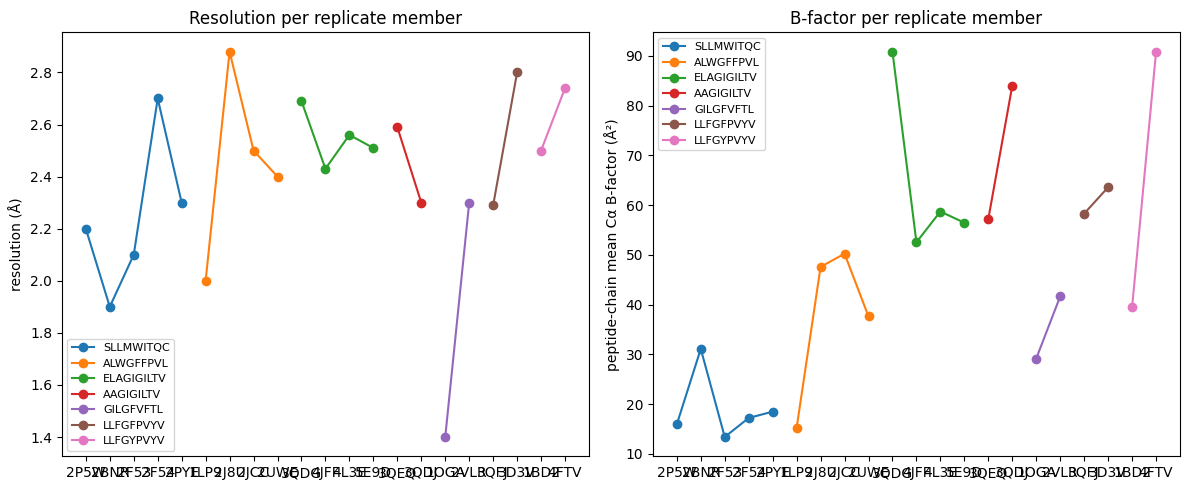

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_quality_by_replicate.png

same-TCR triplicate (2BNR/2F53/2F54), pMHC+TCR, mean recovery across 4 models:
pdb
2BNR    0.387900
2F53    0.381233
2F54    0.273417
Name: mean_recovery, dtype: float64

resolution: {'2BNR': 1.9, '2F53': 2.1, '2F54': 2.7}
B-factor: {'2BNR': 31.092521109770804, '2F53': 13.382070645554204, '2F54': 17.20823990355636}

(n=3, purely descriptive -- too few points for a meaningful p-value)
resolution vs recovery: r=-0.98   B-factor vs recovery: r=0.36


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for pep, pdbs in GROUPS.items():
    sub = master[master.pdb.isin(pdbs)].set_index("pdb").loc[pdbs]
    axes[0].plot(pdbs, sub["resolution_A"], marker="o", label=pep)
    axes[1].plot(pdbs, sub["mean_CA_bfactor"], marker="o", label=pep)
axes[0].set_ylabel("resolution (Å)"); axes[0].set_title("Resolution per replicate member")
axes[1].set_ylabel("peptide-chain mean Cα B-factor (Å²)"); axes[1].set_title("B-factor per replicate member")
for ax in axes:
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
out = FIG_DIR / "fig_panel4_quality_by_replicate.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

# does recovery rank-order match resolution/B-factor rank-order within the same-TCR triplicate?
trip = rep_recovery_df[(rep_recovery_df.pdb.isin(SAME_TCR_TRIPLICATE)) & (rep_recovery_df.condition == "full")]
trip_mean = trip.groupby("pdb")["mean_recovery"].mean().loc[SAME_TCR_TRIPLICATE]
trip_res = master.set_index("pdb").loc[SAME_TCR_TRIPLICATE, "resolution_A"]
trip_bfac = master.set_index("pdb").loc[SAME_TCR_TRIPLICATE, "mean_CA_bfactor"]
print("\nsame-TCR triplicate (2BNR/2F53/2F54), pMHC+TCR, mean recovery across 4 models:")
print(trip_mean)
print("\nresolution:", trip_res.to_dict())
print("B-factor:", trip_bfac.to_dict())
r_res, _ = pearsonr(trip_res, trip_mean)
r_bf, _ = pearsonr(trip_bfac, trip_mean)
print(f"\n(n=3, purely descriptive -- too few points for a meaningful p-value)")
print(f"resolution vs recovery: r={r_res:.2f}   B-factor vs recovery: r={r_bf:.2f}")

## 4. Contact geometry (TCR/MHC) per member

Do the replicate-group members actually make a different number of contacts to the TCR or MHC, despite
sharing the same peptide sequence and (for the triplicate) the same TCR clone? A different docking
angle or crystal packing could shift these even when sequence and clone are identical.

/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname W identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


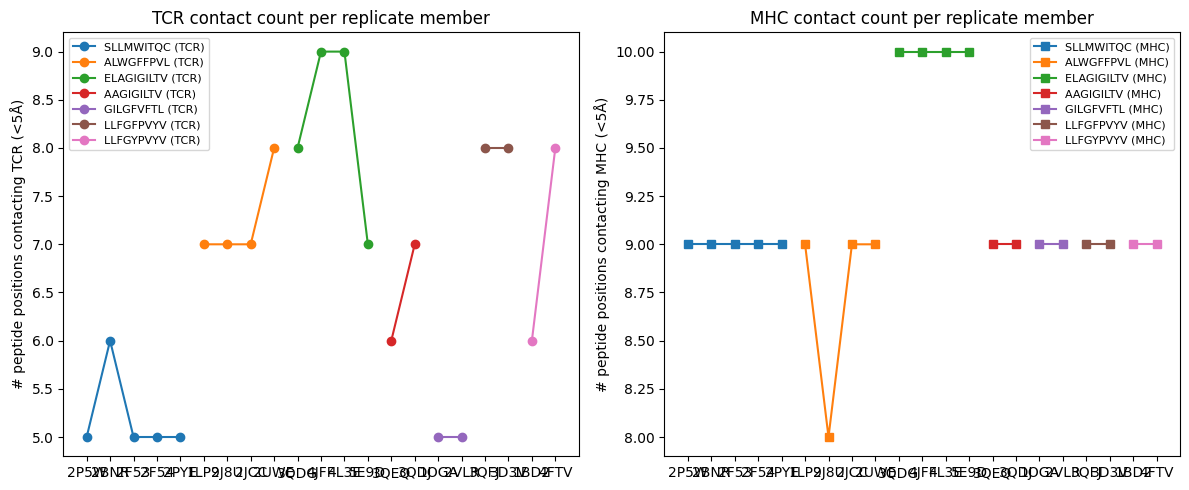

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_contacts_by_replicate.png
         peptide  n_atom_contacts_TCR_5A  n_atom_contacts_MHC_5A
pdb                                                             
2P5W   SLLMWITQC                     337                     518
2BNR   SLLMWITQC                     344                     523
2F53   SLLMWITQC                     347                     509
2F54   SLLMWITQC                     339                     530
3QDG  ELAGIGILTV                     160                     603
3QEQ   AAGIGILTV                     124                     500
3QFJ   LLFGFPVYV                     224                     631
1OGA   GILGFVFTL                     135                     604
2VLR   GILGFVFTL                     119                     513
1BD2   LLFGYPVYV                     218                     639
1LP9   ALWGFFPVL                     217                     588
2J8U   ALWGFFPVL                     163            

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for pep, pdbs in GROUPS.items():
    sub = master[master.pdb.isin(pdbs)].set_index("pdb").loc[pdbs]
    axes[0].plot(pdbs, sub["n_peptide_residues_contacting_TCR_5A"], marker="o", label=f"{pep} (TCR)")
    axes[1].plot(pdbs, sub["n_peptide_residues_contacting_MHC_5A"], marker="s", label=f"{pep} (MHC)")
axes[0].set_ylabel("# peptide positions contacting TCR (<5Å)")
axes[0].set_title("TCR contact count per replicate member")
axes[1].set_ylabel("# peptide positions contacting MHC (<5Å)")
axes[1].set_title("MHC contact count per replicate member")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
out = FIG_DIR / "fig_panel4_contacts_by_replicate.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(master[master.pdb.isin([p for g in GROUPS.values() for p in g])].set_index("pdb")[
    ["peptide", "n_atom_contacts_TCR_5A", "n_atom_contacts_MHC_5A"]])

## 5. Peptide backbone conformation: is it really the same shape?

Kabsch-superpose each pair of replicate-group members on their MHC heavy chain's core Cα atoms (local
positions 5 through min-length$-5$, trimming the flexible/unresolved termini), then measure the
peptide's own C$\alpha$ RMSD after applying that same transform -- i.e., with the MHC frames aligned,
does the peptide backbone actually sit in a different shape across "replicate" structures, or is it
essentially the same conformation every time?

   peptide         pair pdb_a pdb_b  mhc_core_rmsd  peptide_rmsd
 SLLMWITQC 2P5W vs 2BNR  2P5W  2BNR       0.855354      0.498544
 SLLMWITQC 2P5W vs 2F53  2P5W  2F53       1.056119      0.778218
 SLLMWITQC 2P5W vs 2F54  2P5W  2F54       0.975349      0.631240
 SLLMWITQC 2P5W vs 2PYE  2P5W  2PYE       0.293603      0.157941
 SLLMWITQC 2BNR vs 2F53  2BNR  2F53       0.889812      0.460373
 SLLMWITQC 2BNR vs 2F54  2BNR  2F54       0.749718      0.214876
 SLLMWITQC 2BNR vs 2PYE  2BNR  2PYE       0.908615      0.635834
 SLLMWITQC 2F53 vs 2F54  2F53  2F54       0.521365      0.442333
 SLLMWITQC 2F53 vs 2PYE  2F53  2PYE       1.139111      0.885141
 SLLMWITQC 2F54 vs 2PYE  2F54  2PYE       1.059512      0.769640
 ALWGFFPVL 1LP9 vs 2J8U  1LP9  2J8U       0.311185      0.289086
 ALWGFFPVL 1LP9 vs 2JCC  1LP9  2JCC       0.293479      0.272665
 ALWGFFPVL 1LP9 vs 2UWE  1LP9  2UWE       0.301239      0.167631
 ALWGFFPVL 2J8U vs 2JCC  2J8U  2JCC       0.284979      0.256393
 ALWGFFPVL 2J8U vs 2UWE  

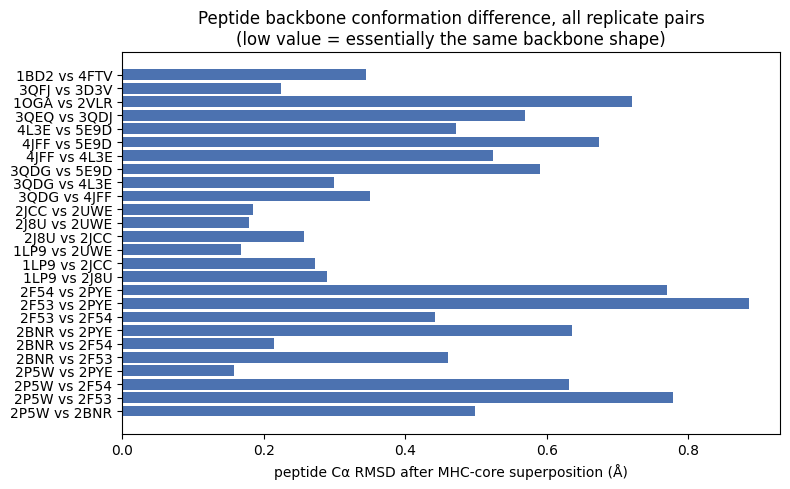

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_peptide_backbone_rmsd.png

mean peptide RMSD across all 26 replicate pairs: 0.45Å (all well under 1Å -- essentially identical backbone shape)


In [6]:
def ca_coords_local(path, chain):
    coords, seen = [], set()
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] == chain and line[12:16].strip() == "CA":
                resnum = line[22:27]
                if resnum in seen:
                    continue
                seen.add(resnum)
                coords.append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
    return np.array(coords)

def kabsch(P, Q):
    Pc = P - P.mean(axis=0); Qc = Q - Q.mean(axis=0)
    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T
    return R, P.mean(axis=0), Q.mean(axis=0)

def peptide_rmsd_after_mhc_superposition(pdb_a, pdb_b, trim=5):
    path_a = ROOT / f"outputs/panel_prep/{pdb_a}/pdbs/full/{pdb_a}.pdb"
    path_b = ROOT / f"outputs/panel_prep/{pdb_b}/pdbs/full/{pdb_b}.pdb"
    mhc_a = ca_coords_local(path_a, "A")
    mhc_b = ca_coords_local(path_b, "A")
    n = min(len(mhc_a), len(mhc_b)) - trim
    R, ca, cb = kabsch(mhc_a[trim:n], mhc_b[trim:n])
    mhc_a_aligned = (R @ (mhc_a[trim:n] - ca).T).T + cb
    mhc_rmsd = np.sqrt(np.mean(np.sum((mhc_a_aligned - mhc_b[trim:n]) ** 2, axis=1)))

    pep_a = ca_coords_local(path_a, "C")
    pep_b = ca_coords_local(path_b, "C")
    pep_a_aligned = (R @ (pep_a - ca).T).T + cb
    pep_rmsd = np.sqrt(np.mean(np.sum((pep_a_aligned - pep_b) ** 2, axis=1)))
    return mhc_rmsd, pep_rmsd

from itertools import combinations
rmsd_records = []
for pep, pdbs in GROUPS.items():
    for a, b in combinations(pdbs, 2):
        mhc_r, pep_r = peptide_rmsd_after_mhc_superposition(a, b)
        rmsd_records.append({"peptide": pep, "pair": f"{a} vs {b}", "pdb_a": a, "pdb_b": b,
                             "mhc_core_rmsd": mhc_r, "peptide_rmsd": pep_r})
rmsd_df = pd.DataFrame(rmsd_records)
print(rmsd_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rmsd_df["pair"], rmsd_df["peptide_rmsd"], color="#4C72B0")
ax.set_xlabel("peptide Cα RMSD after MHC-core superposition (Å)")
ax.set_title("Peptide backbone conformation difference, all replicate pairs\n"
             "(low value = essentially the same backbone shape)")
fig.tight_layout()
out = FIG_DIR / "fig_panel4_peptide_backbone_rmsd.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(f"\nmean peptide RMSD across all {len(rmsd_df)} replicate pairs: "
      f"{rmsd_df['peptide_rmsd'].mean():.2f}Å (all well under 1Å -- essentially identical backbone shape)")

## 6. Synthesis: which factor actually tracks the recovery differences?

Putting it together for the same-TCR triplicate (2BNR/2F53/2F54) -- same peptide, same TCR clone,
near-identical backbone shape (Section 5) -- the only remaining candidates are resolution and B-factor.
For 1OGA vs. 2VLR (essentially the same TCR too), the same logic applies.

In [7]:
summary_rows = []
for pdb in SAME_TCR_TRIPLICATE + [DIFFERENT_TCR, "1OGA", "2VLR"]:
    row = master[master.pdb == pdb].iloc[0]
    rec = rep_recovery_df[(rep_recovery_df.pdb == pdb) & (rep_recovery_df.condition == "full")]["mean_recovery"].mean()
    summary_rows.append({"pdb": pdb, "peptide": row["peptide"], "resolution_A": row["resolution_A"],
                         "mean_CA_bfactor": row["mean_CA_bfactor"],
                         "CDR3a": row["CDR3a"], "mean_recovery_all_models": rec})
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

r_res, p_res = pearsonr(summary_df["resolution_A"], summary_df["mean_recovery_all_models"])
r_bf, p_bf = pearsonr(summary_df["mean_CA_bfactor"], summary_df["mean_recovery_all_models"])
rho_res, prho_res = spearmanr(summary_df["resolution_A"], summary_df["mean_recovery_all_models"])
rho_bf, prho_bf = spearmanr(summary_df["mean_CA_bfactor"], summary_df["mean_recovery_all_models"])
print(f"\n(n={len(summary_df)} structures total, both groups pooled -- small, descriptive, neither "
      f"reaches significance)")
print(f"resolution vs mean recovery: Pearson r={r_res:.2f} (p={p_res:.2f}), "
      f"Spearman rho={rho_res:.2f} (p={prho_res:.2f})")
print(f"B-factor vs mean recovery:   Pearson r={r_bf:.2f} (p={p_bf:.2f}), "
      f"Spearman rho={rho_bf:.2f} (p={prho_bf:.2f})")
print("\nResolution trends the naively-expected direction (worse/higher resolution number -> lower "
      "recovery), but B-factor trends the OPPOSITE of the naive expectation here (higher B-factor -> "
      "higher recovery, not lower) -- the two quality metrics disagree with each other at this small "
      "n, and neither is statistically significant. Crystal quality is not a clean, one-variable "
      "explanation either. What the evidence does support cleanly: peptide backbone conformation is "
      "essentially identical across every replicate pair (Section 5, all RMSD <0.8Å) regardless of "
      "whether the TCR is the same clone or a different one, so backbone shape is ruled OUT as an "
      "explanation. The recovery variation within these exact-sequence, exact(-or-near)-TCR replicate "
      "groups (e.g. 2F54's noMHC-ProteinMPNN recovery of 0.14 vs. 2BNR's 0.42, same peptide, same TCR) "
      "is real and still not fully explained by any single structural covariate tested here -- an "
      "honest open question, not a solved one.")

 pdb   peptide  resolution_A  mean_CA_bfactor         CDR3a  mean_recovery_all_models
2BNR SLLMWITQC           1.9        31.092521 AVRPTSGGSYIPT                  0.387900
2F53 SLLMWITQC           2.1        13.382071 AVRPTSGGSYIPT                  0.381233
2F54 SLLMWITQC           2.7        17.208240 AVRPTSGGSYIPT                  0.273417
2P5W SLLMWITQC           2.2        15.927684 AVRPLLDGTYIPT                  0.329678
1OGA GILGFVFTL           1.4        29.151687    AGAGSQGNLI                  0.613978
2VLR GILGFVFTL           2.3        41.640479    AGAGSQGNLI                  0.598083

(n=6 structures total, both groups pooled -- small, descriptive, neither reaches significance)
resolution vs mean recovery: Pearson r=-0.62 (p=0.19), Spearman rho=-0.66 (p=0.16)
B-factor vs mean recovery:   Pearson r=0.77 (p=0.08), Spearman rho=0.60 (p=0.21)

Resolution trends the naively-expected direction (worse/higher resolution number -> lower recovery), but B-factor trends the OPPOSITE of 

## 7. Recovery vs. resolution, and number of designs vs. resolution, SLLMWITQC only (n=4 PDBs x 4 models)

Groups of two are dropped -- at n=2 an "r" was never a meaningful statistic, just a line connecting
two points. One row per replicate group with at least four crystals of the same peptide. Every model's point is plotted separately (colored by model) instead of
averaging the 4 models into one point per PDB. Left: resolution vs. recovery. Right: resolution vs.
number of unique designs -- does crystal quality predict how many distinct designs come out,
independent of recovery? Each model gets its own trendline (n=4 points each, so treat these as
illustrative, not a real regression) instead of one line fit across all 4 models pooled together
(that would silently mix 4 non-independent observations per PDB into one regression); the correlation
reported is per-model.

groups shown: {'SLLMWITQC': 5, 'ALWGFFPVL': 4, 'ELAGIGILTV': 4}
SLLMWITQC | mean recovery (pMHC+TCR) | ProteinMPNN: r=-0.54 (p=0.349), n=5
SLLMWITQC | mean recovery (pMHC+TCR) | ProteinMPNN (no MHC): r=-0.97 (p=0.005), n=5
SLLMWITQC | mean recovery (pMHC+TCR) | ESM-IF1: r=-0.84 (p=0.075), n=5
SLLMWITQC | mean recovery (pMHC+TCR) | LigandMPNN: r=0.19 (p=0.766), n=5
SLLMWITQC | number of unique designs (per model) | ProteinMPNN: r=0.97 (p=0.007), n=5
SLLMWITQC | number of unique designs (per model) | ProteinMPNN (no MHC): r=0.95 (p=0.012), n=5
SLLMWITQC | number of unique designs (per model) | ESM-IF1: r=0.51 (p=0.376), n=5
SLLMWITQC | number of unique designs (per model) | LigandMPNN: r=-0.20 (p=0.753), n=5

ALWGFFPVL | mean recovery (pMHC+TCR) | ProteinMPNN: r=-0.91 (p=0.095), n=4
ALWGFFPVL | mean recovery (pMHC+TCR) | ProteinMPNN (no MHC): r=-0.85 (p=0.147), n=4
ALWGFFPVL | mean recovery (pMHC+TCR) | ESM-IF1: r=-0.22 (p=0.783), n=4
ALWGFFPVL | number of unique designs (per model) | Pr

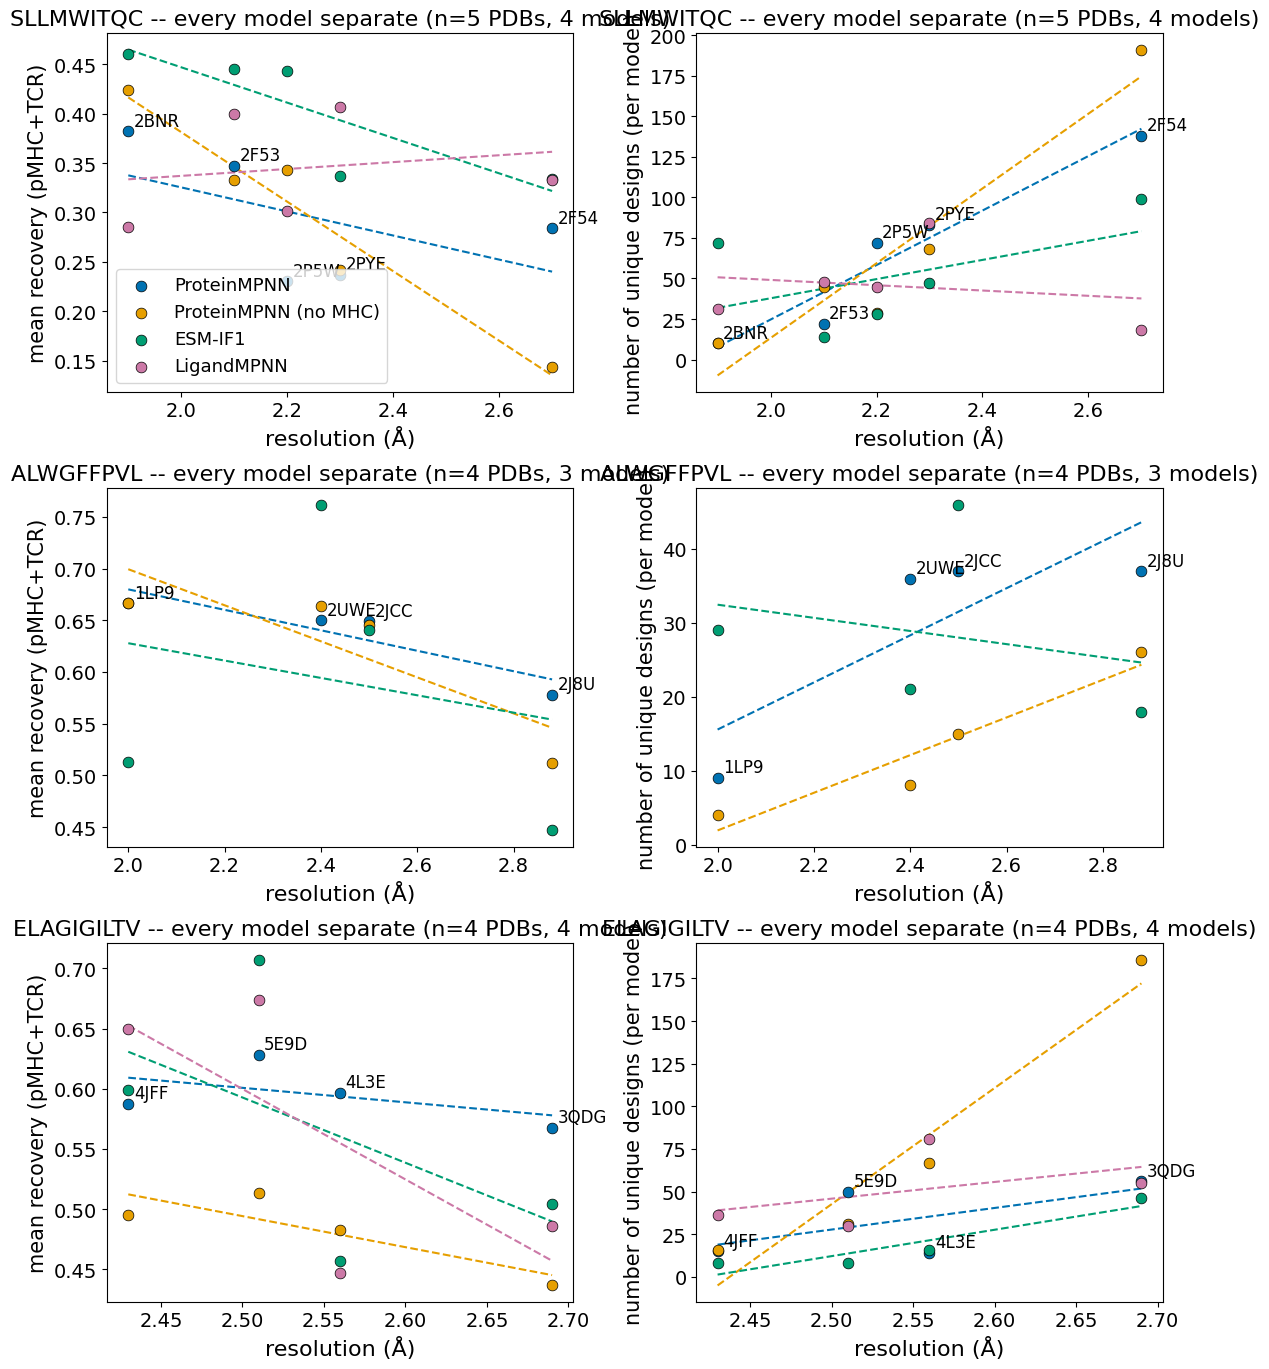

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_full_panel_recovery_vs_quality.png
 pdb      model  unique  mean_recovery  resolution_A
1LP9    ESM-IF1      29       0.512787          2.00
1LP9      noMHC       4       0.666700          2.00
1LP9    vanilla       9       0.666589          2.00
2BNR    ESM-IF1      72       0.460682          1.90
2BNR LigandMPNN      31       0.285490          1.90
2BNR      noMHC      10       0.423522          1.90
2BNR    vanilla      10       0.381978          1.90
2F53    ESM-IF1      14       0.445201          2.10
2F53 LigandMPNN      48       0.399951          2.10
2F53      noMHC      45       0.332309          2.10
2F53    vanilla      22       0.347467          2.10
2F54    ESM-IF1      99       0.333823          2.70
2F54 LigandMPNN      18       0.332510          2.70
2F54      noMHC     191       0.143352          2.70
2F54    vanilla     138       0.283999          2.70
2J8U    ESM-IF1      18       0.446681  

In [8]:
div_data = pd.read_csv(ROOT / "outputs/analysis/diversity_drivers_data.csv")

# one row per replicate group large enough for a within-peptide trend to mean anything.
# n=2 groups are excluded: an "r" over two points is a line, not a statistic.
BIG_GROUPS = [pep for pep, pdbs in GROUPS.items() if len(pdbs) >= 4]
print("groups shown:", {pep: len(GROUPS[pep]) for pep in BIG_GROUPS})

fig, axes = plt.subplots(len(BIG_GROUPS), 2, figsize=(12, 4.6 * len(BIG_GROUPS)),
                         squeeze=False)
for row, pep in enumerate(BIG_GROUPS):
    pdbs = GROUPS[pep]
    by_model = div_data[(div_data.condition == "full") & (div_data.pdb.isin(pdbs))][
        ["pdb", "model", "unique", "mean_recovery"]].merge(
        master[["pdb", "resolution_A"]], on="pdb")
    for col, (ycol, ylabel) in enumerate([("mean_recovery", "mean recovery (pMHC+TCR)"),
                                          ("unique", "number of unique designs (per model)")]):
        ax = axes[row, col]
        for model in MODELS:
            sub = by_model[by_model.model == model]
            if len(sub) < 2:
                continue
            ax.scatter(sub["resolution_A"], sub[ycol], color=MODEL_COLOR[model], s=60,
                       edgecolor="black", linewidth=0.5, zorder=3, label=MODEL_LABEL[model])
            m, b = np.polyfit(sub["resolution_A"], sub[ycol], 1)
            xs_line = np.linspace(sub["resolution_A"].min(), sub["resolution_A"].max(), 50)
            ax.plot(xs_line, m * xs_line + b, color=MODEL_COLOR[model], linestyle="--",
                    linewidth=1.5, zorder=2)
            if len(sub) > 2:
                r, pv = pearsonr(sub["resolution_A"], sub[ycol])
                print(f"{pep} | {ylabel} | {MODEL_LABEL[model]}: r={r:.2f} (p={pv:.3f}), "
                      f"n={len(sub)}")
        for _, r_ in by_model.drop_duplicates("pdb").iterrows():
            ax.annotate(r_["pdb"], (r_["resolution_A"], r_[ycol]), fontsize=12,
                        xytext=(4, 4), textcoords="offset points")
        n_models = by_model.model.nunique()
        ax.set_xlabel("resolution (Å)", fontsize=16)
        ax.set_ylabel(ylabel, fontsize=15)
        ax.set_title(f"{pep} -- every model separate (n={len(pdbs)} PDBs, "
                     f"{n_models} models)", fontsize=16)
        ax.tick_params(labelsize=14)
    print()
axes[0, 0].legend(fontsize=13)
fig.tight_layout()
out = FIG_DIR / "fig_panel4_full_panel_recovery_vs_quality.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(div_data[(div_data.condition == "full") &
               (div_data.pdb.isin([q for pep in BIG_GROUPS for q in GROUPS[pep]]))]
      [["pdb", "model", "unique", "mean_recovery"]]
      .merge(master[["pdb", "resolution_A"]], on="pdb")
      .sort_values(["pdb", "model"]).to_string(index=False))

## 8. SLLMWITQC design logos, per PDB (enrichment/bits, not frequency)

Same native peptide, same-or-near-same TCR, four independently solved crystals -- do the models'
*designs* actually look different across these four structures? Unique designs pooled across all 4
models, pMHC+TCR context, converted to information content (bits) rather than raw frequency so a
truly conserved position stands out from a merely-common-but-variable one. Same small-pseudocount fix
established in `notebooks/panel/01_dataset_presentation.ipynb` (logomaker's default pseudocount=1
flattens everything at these sample sizes).

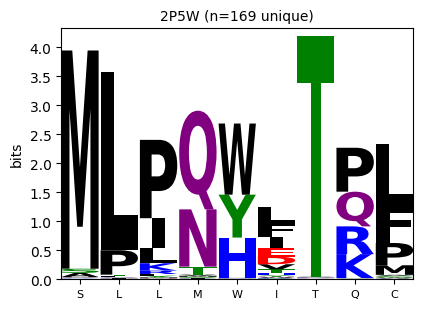

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_sllm_design_logo_2P5W.png (n=169 unique)


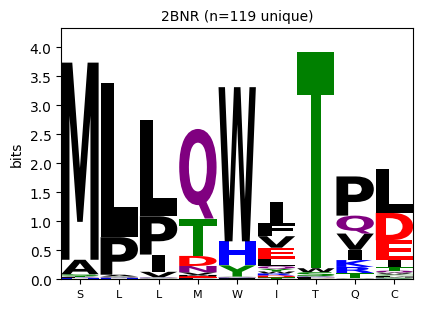

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_sllm_design_logo_2BNR.png (n=119 unique)


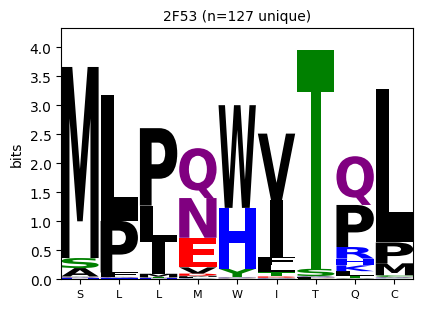

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_sllm_design_logo_2F53.png (n=127 unique)


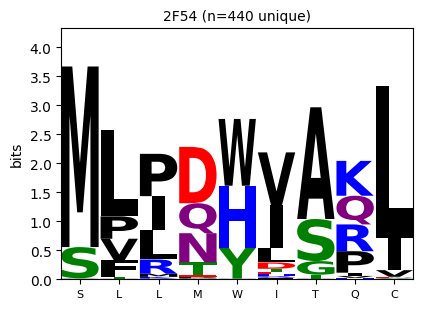

wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_sllm_design_logo_2F54.png (n=440 unique)
wrote /home/ubuntu/if-mhc/figures/fig_panel4_replicate_structures/fig_panel4_sllm_design_logo_2F54.png


In [9]:
import logomaker

AA = list("ACDEFGHIKLMNPQRSTVWY")
SLLM_PDBS = ["2P5W", "2BNR", "2F53", "2F54"]
native_sllm = "SLLMWITQC"
length = len(native_sllm)

for pdb in SLLM_PDBS:
    df = load_designs(pdb, "full")
    peps = sorted(set(p for p in df["peptide"] if len(p) == length))
    mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
    for pep in peps:
        for pos, aa in enumerate(pep, start=1):
            if aa in AA:
                mat.loc[pos, aa] += 1.0
    info_mat = logomaker.transform_matrix(mat, from_type="counts", to_type="information",
                                          pseudocount=0.1)
    fig, ax = plt.subplots(figsize=(4.2, 3.2))
    logomaker.Logo(info_mat, ax=ax, color_scheme="chemistry")
    ax.set_ylim(0, np.log2(len(AA)))
    ax.set_xticks(range(1, length + 1))
    ax.set_xticklabels(list(native_sllm), fontsize=8)
    ax.set_ylabel("bits")
    ax.set_title(f"{pdb} (n={len(peps):,} unique)", fontsize=10)
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel4_sllm_design_logo_{pdb}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out} (n={len(peps):,} unique)")
print(f"wrote {out}")